In [9]:
from ase.io import Trajectory
from ase.io import read
import matplotlib.pyplot as plt
import numpy as np
import torch
import os

In [28]:
# ---- PHYSICAL CONSTANTS for density ----
AMU_TO_KG       = 1.66053906660e-27   # kg per atomic mass unit
ANGSTROM3_TO_M3 = 1e-30               # Å³ → m³

def get_supported_extractors():
    """Return a dict of property extractors for image objects including density, using recommended .calc style to avoid warnings."""
    return {
        'potential_energy': lambda img: img.calc.get_potential_energy() if getattr(img, 'calc', None) is not None else np.nan,
        'forces': lambda img: img.calc.get_forces() if getattr(img, 'calc', None) is not None else np.nan,
        'temperature': lambda img: img.get_temperature() if hasattr(img, 'get_temperature') else np.nan,
        'volume': lambda img: img.get_volume() if hasattr(img, 'get_volume') else np.nan,
        'size': lambda img: len(img),
        'density': lambda img: ((img.get_masses().sum() * AMU_TO_KG) / (img.get_volume() * ANGSTROM3_TO_M3) / 1000.0)
                    if (hasattr(img, 'get_masses') and hasattr(img, 'get_volume')) else np.nan,
    }

def extract_values_from_traj(traj_path, query, stride=1, start_frame=0, end_frame=None):
    """
    Extract values for a given query from a trajectory file, with stride, start_frame, and end_frame.
    If end_frame is None, extracts up to the last frame.
    """
    extractors = get_supported_extractors()
    if query not in extractors:
        raise ValueError(f"Unsupported query '{query}'. Supported: {list(extractors.keys())}")

    with Trajectory(traj_path, mode='r') as traj:
        n_total = len(traj)
        stop = end_frame if end_frame is not None else n_total
        stop = min(stop, n_total)
        idx_list = list(range(start_frame, stop, stride))
        print(f"Number of images (stride={stride}, start_frame={start_frame}, end_frame={stop}): {len(idx_list)}")
        values = [extractors[query](traj[i]) for i in idx_list]

        # For `forces`, convert to mean norm for scalar plotting
        if query == 'forces':
            values = [np.linalg.norm(f, axis=1).mean() if not isinstance(f, float) else np.nan for f in values]
    return values, len(values)

def get_units_map():
    """Return a dict of units for the known properties."""
    return {
        'potential_energy': 'eV',
        'forces': 'eV/Å',
        'temperature': 'K',
        'volume': 'Å³',
        'size': 'atoms',
        'density': 'g/cm³',
    }

def compute_mean_std(values):
    """Return (mean, std) for a list/array, skipping NaNs."""
    arr = np.asarray(values)
    arr = arr[np.isfinite(arr)]
    if len(arr) == 0:
        return np.nan, np.nan
    return np.mean(arr), np.std(arr)

def plot_all_properties_together(traj_path, stride=1, start_frame=0, end_frame=None):
    """
    Plot all supported properties for a given trajectory on separate subplots in one figure.
    Now supports an end_frame argument (exclusive).
    """
    extractors = get_supported_extractors()
    ylabel_map = {
        'potential_energy': 'Potential Energy (eV)',
        'forces': 'Force Norm (eV/Å)',
        'temperature': 'Temperature (K)',
        'volume': 'Volume (Å³)',
        'size': 'Number of Atoms',
        'density': 'Density (g/cm³)',
    }
    units_map = get_units_map()
    
    n_plots = len(extractors)
    # Set up the figure size and layout
    fig, axs = plt.subplots(n_plots, 1, figsize=(10, 2.2 * n_plots), sharex=True)
    if n_plots == 1:
        axs = [axs]
    properties_list = list(extractors.keys())
    
    # If end_frame is None, use full length for time axis
    with Trajectory(traj_path, mode='r') as traj:
        n_total = len(traj)
        stop = end_frame if end_frame is not None else n_total
        stop = min(stop, n_total)
        n_timepoints = len(range(start_frame, stop, stride))

    for i, query in enumerate(properties_list):
        print(f"\nPreparing to plot: {query}")
        try:
            values, n = extract_values_from_traj(traj_path, query, stride, start_frame, end_frame)
            mean_val, std_val = compute_mean_std(values)
            units = units_map.get(query, "")

            time_indices = list(range(start_frame, start_frame + n * stride, stride))
            # If exceeding stop, trim to correct times (since last stride may overshoot stop)
            time_indices = [ix for ix in time_indices if ix < stop]
            time_fs = np.array(time_indices) * 10  # Frame indices * 10 fs
            time_ns = time_fs / 1e6  # Convert fs to ns

            label = ylabel_map.get(query, query)
            stat_info = f"(mean={mean_val:.4g}±{std_val:.2g} {units})" if (mean_val is not None and std_val is not None and units) else ""
            axs[i].plot(time_ns, values[:len(time_ns)], marker='o', linestyle='-', markersize=2)
            axs[i].set_ylabel(label)
            axs[i].set_title(f"{label} {stat_info}")
            
        except Exception as e:
            axs[i].text(0.5, 0.5, f"Failed to plot {query}:\n{e}", ha='center', va='center', transform=axs[i].transAxes)
            axs[i].set_ylabel(ylabel_map.get(query, query))
            axs[i].set_title(f"{ylabel_map.get(query, query)} (ERROR)")
            print(f"Failed to plot {query}: {e}")
    axs[-1].set_xlabel('Time (ns)')

    # Convert stride, start_frame, and end_frame to ns for the title
    stride_fs = stride * 10
    stride_ns = stride_fs / 1e6
    start_frame_fs = start_frame * 10
    start_frame_ns = start_frame_fs / 1e6
    end_frame_ns = (end_frame * 10 / 1e6) if end_frame is not None else (n_total * 10 / 1e6)

    # Generate custom trajectory label: last 3 path components joined with '-' instead of '/'
    traj_parts = os.path.normpath(traj_path).split(os.sep)
    traj_custom_title = '-'.join(traj_parts[-3:]) if len(traj_parts) >= 3 else os.path.basename(traj_path)

    fig.suptitle(
        f'All Trajectory Extractors (stride={stride_ns:.6g} ns, start={start_frame_ns:.6g} ns, end={end_frame_ns:.6g} ns):\n {traj_custom_title}',
        fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


Preparing to plot: potential_energy
Number of images (stride=5000, start_frame=100000, end_frame=2000000): 380

Preparing to plot: forces
Number of images (stride=5000, start_frame=100000, end_frame=2000000): 380

Preparing to plot: temperature
Number of images (stride=5000, start_frame=100000, end_frame=2000000): 380

Preparing to plot: volume
Number of images (stride=5000, start_frame=100000, end_frame=2000000): 380

Preparing to plot: size
Number of images (stride=5000, start_frame=100000, end_frame=2000000): 380

Preparing to plot: density
Number of images (stride=5000, start_frame=100000, end_frame=2000000): 380


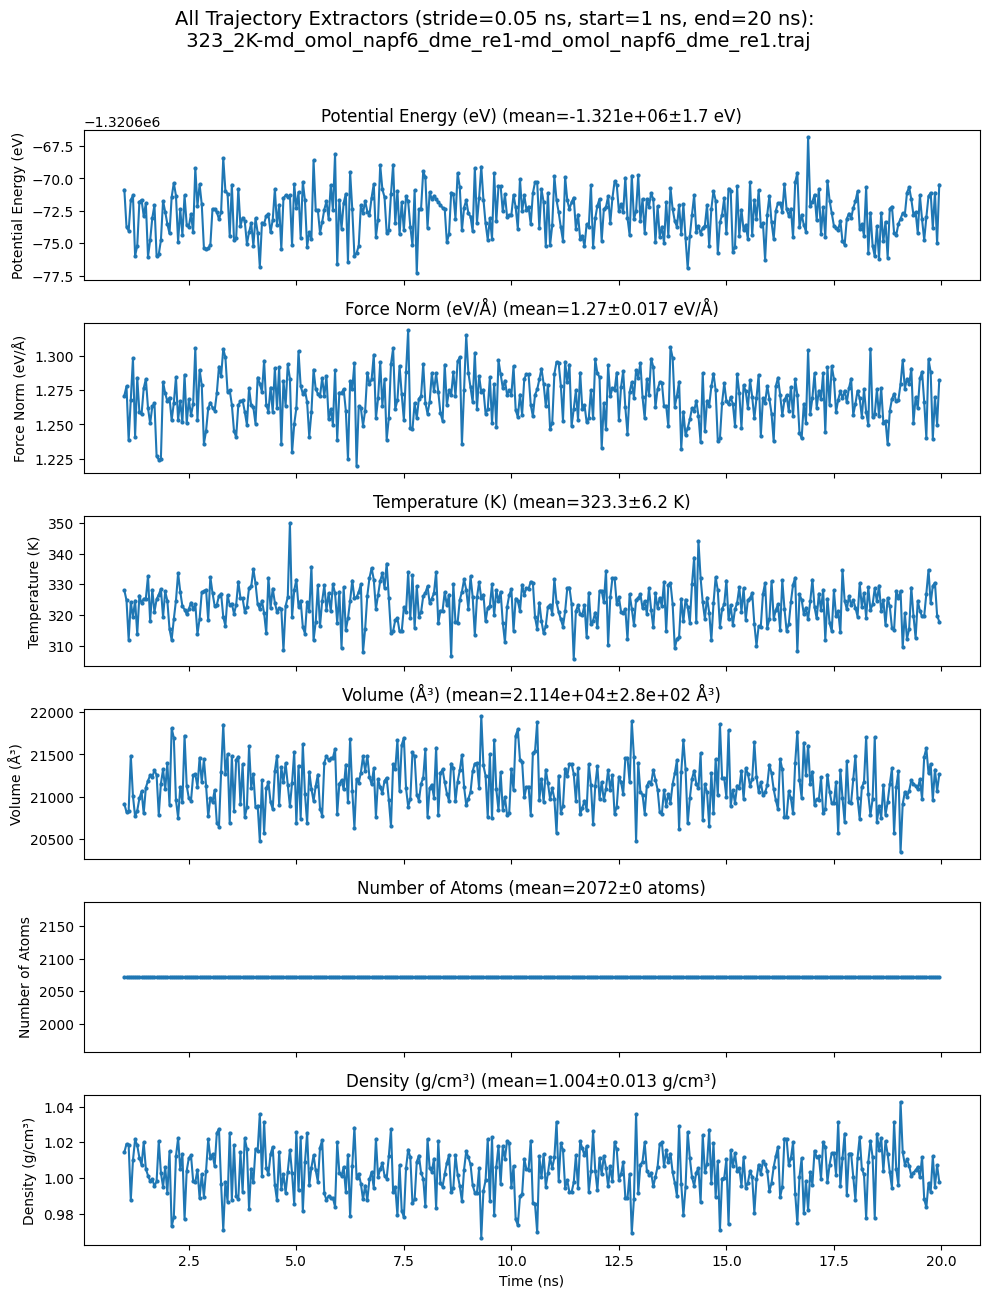

In [36]:
traj_path = "/global/homes/y/yuejian/project/MLFF-distill/yuejian/electrolyte_application/ablate_distillation/ablation_diffusivity/20ns_solvent_solute_0.5M/323_2K/md_omol_napf6_dme_re1/md_omol_napf6_dme_re1.traj"

plot_all_properties_together(traj_path, stride=5000, start_frame=100000, end_frame=2000000)